In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout, Flatten,LSTM,GRU,LayerNormalization
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error ,mean_absolute_error

In [2]:
clns=["unit_number","time_cycles","op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]
fe=["op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1, 22)]

print(len(clns))

26


In [3]:
train_1=pd.read_csv("./nasa/train_FD001.txt",sep=r"\s+",header=None,names=clns)

In [4]:
test_1=pd.read_csv("./nasa/test_FD001.txt",sep=r"\s+",header=None,names=clns)

In [5]:
rul_1=pd.read_csv("./nasa/rul_FD001.txt",sep=r"\s+",header=None,names=["rul"])

In [6]:
mx_c=train_1.groupby("unit_number")["time_cycles"].transform("max")
train_1["rul"]=(mx_c-train_1["time_cycles"]).clip(upper=125)

In [7]:
sc=MinMaxScaler()
train_1[fe]=sc.fit_transform(train_1[fe])
test_1[fe]=sc.transform(test_1[fe])

In [8]:
uni=train_1["unit_number"].unique()
np.random.seed(42)
np.random.shuffle(uni)

n_train=int(len(uni)* 0.8)
train_uni=uni[:n_train]
val_uni=uni[n_train:]

In [9]:
s_l=30
xl=[]
yl=[]
for i in train_uni:
    en_data=train_1[train_1["unit_number"]==i].sort_values("time_cycles")
    data=en_data[fe].values
    rul_val=en_data["rul"].values
    for j in range(0,len(data)-s_l+1):
        wi=data[j:j+s_l]
        tar=rul_val[j+s_l-1]
        xl.append(wi)
        yl.append(tar)
x_train=np.array(xl)
y_train=np.array(yl)

In [10]:
xl_val,yl_val=[],[]
for i in val_uni:
    en_data=train_1[train_1["unit_number"]==i].sort_values("time_cycles")
    data=en_data[fe].values
    rul_val=en_data["rul"].values

    for j in range(len(data)-s_l+1):
        wi=data[j:j+s_l]
        tar=rul_val[j+s_l-1]
        xl_val.append(wi)
        yl_val.append(tar)

x_val=np.array(xl_val)
y_val=np.array(yl_val)

In [11]:
print(len(fe))

24


In [12]:
model=Sequential()
model.add(GRU(64,return_sequences=True,input_shape=(s_l,24)))
model.add(Dropout(0.4))
model.add(GRU(16,return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
compile=model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,233 (82.94 KB)

 Trainable params: 21,233 (82.94 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
sc2=MinMaxScaler()

y_train_sc=sc2.fit_transform(y_train.reshape(-1,1))
y_val_sc=sc2.transform(y_val.reshape(-1,1))

In [16]:
erl=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1)
ckp=ModelCheckpoint("bst_modelFD001.keras",monitor='val_loss',save_best_only=True,verbose=1)

In [17]:
history=model.fit(x_train,y_train_sc,validation_data=(x_val,y_val_sc),epochs=100,batch_size=32,callbacks=[erl,ckp])

Epoch 1/100
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0916 - mae: 0.2356
Epoch 1: val_loss improved from None to 0.02901, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0620 - mae: 0.1964 - val_loss: 0.0290 - val_mae: 0.1413
Epoch 2/100
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0433 - mae: 0.1668
Epoch 2: val_loss improved from 0.02901 to 0.02581, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0413 - mae: 0.1630 - val_loss: 0.0258 - val_mae: 0.1249
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0319 - mae: 0.1433
Epoch 3: val_loss improved from 0.02581 to 0.01713, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0289 - mae: 0.1362 - val_loss: 0.0171 - val_mae: 0.1057
Epoch 4/100
433/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0233 - mae: 0.1219
Epoch 4: val_loss improved from 0.01713 to 0.01587, saving model to bst_modelFD001.k

In [19]:
l_model=load_model("bst_modelFD001.keras")
y_pre_sc=l_model.predict(x_val)
y_pred=sc2.inverse_transform(y_pre_sc)


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [20]:
Rmse=np.sqrt(mean_squared_error(y_val,y_pred))
mae=mean_absolute_error(y_val,y_pred)

print(f"rmse: {Rmse:.2f}")
print(f"mae: {mae:.2f}")

rmse: 13.39
mae: 9.31


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


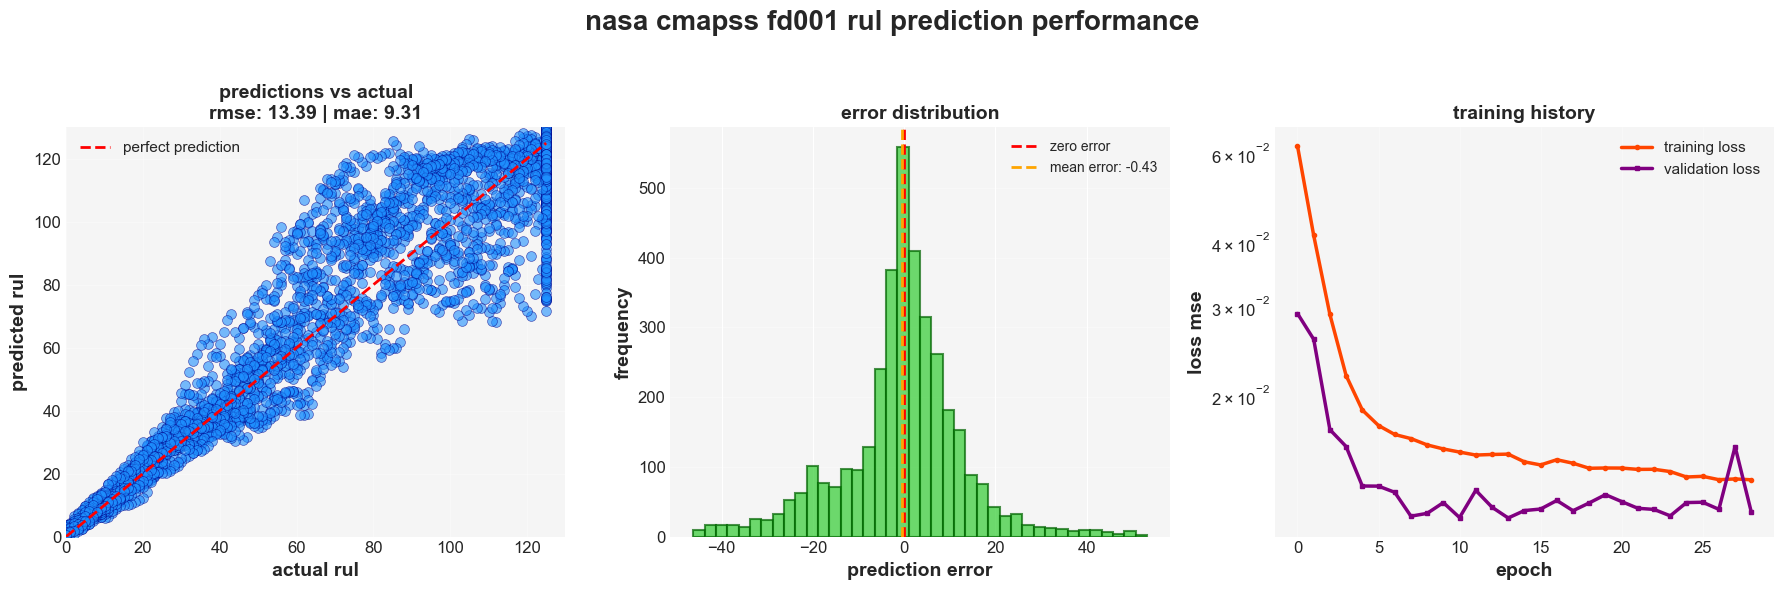

rmse: 13.39
mae: 9.31
accuracy: 89.3%


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.facecolor']='white'
plt.rcParams['axes.facecolor']='whitesmoke'
plt.rcParams['font.size']=12
plt.rcParams['axes.labelsize']=14
plt.rcParams['axes.titlesize']=16

from tensorflow.keras.models import load_model
bst_model=load_model("bst_modelFD001.keras")
y_pred_sc=bst_model.predict(x_val)
y_pred=sc2.inverse_transform(y_pred_sc).flatten()

rmse=np.sqrt(mean_squared_error(y_val,y_pred))
mae=mean_absolute_error(y_val,y_pred)

fig=plt.figure(figsize=(18,6))
fig.suptitle('nasa cmapss fd001 rul prediction performance',fontsize=20,fontweight='bold',y=0.98)

ax1=plt.subplot(1,3,1)
scatter=ax1.scatter(y_val,y_pred,alpha=0.6,c='dodgerblue',edgecolors='darkblue',s=50,linewidth=0.5)
ax1.plot([0, 125],[0, 125], 'r--',linewidth=2,label='perfect prediction')
ax1.set_xlabel('actual rul',fontweight='bold')
ax1.set_ylabel('predicted rul',fontweight='bold')
ax1.set_title(f'predictions vs actual\nrmse: {rmse:.2f} | mae: {mae:.2f}',fontweight='bold',fontsize=14)
ax1.legend(fontsize=11,loc='upper left')
ax1.grid(True,alpha=0.3)
ax1.set_xlim(0,130)
ax1.set_ylim(0,130)

ax2=plt.subplot(1, 3, 2)
errors=y_val-y_pred
ax2.hist(errors,bins=40,color='limegreen',alpha=0.7,edgecolor='darkgreen',linewidth=1.5)
ax2.axvline(x=0, color='red',linestyle='--',linewidth=2,label='zero error')
ax2.axvline(x=np.mean(errors),color='orange',linestyle='--',linewidth=2, label=f'mean error: {np.mean(errors):.2f}')
ax2.set_xlabel('prediction error',fontweight='bold')
ax2.set_ylabel('frequency',fontweight='bold')
ax2.set_title('error distribution',fontweight='bold',fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True,alpha=0.3, axis='y')

ax3=plt.subplot(1,3,3)
ax3.plot(history.history['loss'],label='training loss',color='orangered',linewidth=2.5,marker='o',markersize=3)
ax3.plot(history.history['val_loss'],label='validation loss',color='purple',linewidth=2.5,marker='s',markersize=3)
ax3.set_xlabel('epoch',fontweight='bold')
ax3.set_ylabel('loss mse',fontweight='bold')
ax3.set_title('training history',fontweight='bold',fontsize=14)
ax3.legend(fontsize=11,loc='upper right')
ax3.grid(True,alpha=0.3)
ax3.set_yscale('log')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

print(f"rmse: {rmse:.2f}")
print(f"mae: {mae:.2f}")
print(f"accuracy: {100*(1-rmse/125):.1f}%")

In [2]:
def prepare_data(name,s_l=30,val_ratio=0.2,seed=42):
    clns=["unit_number","time_cycles","op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]
    fe=["op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]

    train=pd.read_csv(f"./nasa/train_{name}.txt",sep=r"\s+",header=None,names=clns)
    test=pd.read_csv(f"./nasa/test_{name}.txt",sep=r"\s+", header=None,names=clns)
    rul=pd.read_csv(f"./nasa/RUL_{name}.txt",sep=r"\s+",header=None, names=["rul"])

    mx_c=train.groupby("unit_number")["time_cycles"].transform("max")
    train["rul"]=(mx_c-train["time_cycles"]).clip(upper=125)

    sc=MinMaxScaler()
    train[fe]=sc.fit_transform(train[fe])
    test[fe]=sc.transform(test[fe])

    units=train["unit_number"].unique()
    np.random.seed(seed)
    np.random.shuffle(units)

    n_train=int(len(units)*(1-val_ratio))
    train_uni=units[:n_train]
    val_uni=units[n_train:]

    xl_train,yl_train=[],[]
    for i in train_uni:
        en_data=train[train["unit_number"]==i].sort_values("time_cycles")
        data=en_data[fe].values
        rul_val=en_data["rul"].values

        for j in range(len(data)-s_l+1):
            xl_train.append(data[j:j+s_l])
            yl_train.append(rul_val[j+s_l-1])

    x_train=np.array(xl_train)
    y_train=np.array(yl_train)

    xl_val,yl_val=[],[]
    for i in val_uni:
        en_data=train[train["unit_number"]==i].sort_values("time_cycles")
        data=en_data[fe].values
        rul_val=en_data["rul"].values

        for j in range(len(data)-s_l+1):
            xl_val.append(data[j:j+s_l])
            yl_val.append(rul_val[j+s_l-1])

    x_val=np.array(xl_val)
    y_val=np.array(yl_val)

    return x_train,y_train,x_val,y_val,test,rul,sc

In [3]:
x_train2,y_train2,x_val2,y_val2,test_2,rul_2,sc_2=prepare_data("FD002",s_l=30,val_ratio=0.2,seed=42)
print("train shape:",x_train2.shape,y_train2.shape)
print("test shape:",test_2.shape)
print("val shape",x_val2.shape,y_val2.shape)


train shape: (36857, 30, 24) (36857,)
test shape: (33991, 26)
val shape (9362, 30, 24) (9362,)


In [4]:
sc2=MinMaxScaler()
y_train2_sc=sc2.fit_transform(y_train2.reshape(-1,1))
y_val2_sc=sc2.transform(y_val2.reshape(-1,1))

In [5]:
print("x_train2 shape:",x_train2.shape)
print("timestep",x_train2.shape[1])
print("features:",x_train2.shape[2])

x_train2 shape: (36857, 30, 24)
timestep 30
features: 24


In [6]:
model2=Sequential()
model2.add(GRU(64,return_sequences=True,input_shape=(30,24)))
model2.add(Dropout(0.3))
model2.add(GRU(32,return_sequences=False))
model2.add(Dropout(0.2))
model2.add(Dense(1))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
compile2=model2.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [8]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,721 (104.38 KB)

 Trainable params: 26,721 (104.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
ckp2=ModelCheckpoint("bst_modelFD002.keras",monitor='val_loss',save_best_only=True,verbose=1)
erl2=EarlyStopping(monitor='val_loss',patience=15,verbose=1)

In [10]:
history=model2.fit(x_train2,y_train2_sc,validation_data=(x_val2,y_val2_sc),epochs=50,batch_size=32,callbacks=[ckp2,erl2])

Epoch 1/50
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1012 - mae: 0.2622
Epoch 1: val_loss improved from None to 0.04038, saving model to bst_modelFD002.keras
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0702 - mae: 0.2164 - val_loss: 0.0404 - val_mae: 0.1667
Epoch 2/50
1150/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0444 - mae: 0.1718
Epoch 2: val_loss did not improve from 0.04038
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0444 - mae: 0.1719 - val_loss: 0.0406 - val_mae: 0.1669
Epoch 3/50
1150/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0403 - mae: 0.1634
Epoch 3: val_loss improved from 0.04038 to 0.03363, saving model to bst_modelFD002.keras
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0391 - mae: 0.1605 - val_loss: 0.0336 - val_mae: 0.1533
Epoch 4/50
1151/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0346 - mae: 0.1502
Epoch 4: val_loss improved from 0.03363 to 0.02932, saving model to bst_modelFD002.keras
1152/1152 ━━━━━━━━━━

In [11]:
l_model2=load_model("bst_modelFD002.keras")
y_pre_sc2=l_model2.predict(x_val2)
y_pred2=sc2.inverse_transform(y_pre_sc2)

Rmse2=np.sqrt(mean_squared_error(y_val2,y_pred2))
mae2=mean_absolute_error(y_val2,y_pred2)

print(f"rmse: {Rmse2:.2f}")
print(f"mae: {mae2:.2f}")

293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
rmse: 17.63
mae: 13.26


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------

In [4]:
x_train3,y_train3,x_val3,y_val3,test_3,rul_3,sc_3=prepare_data("FD003",s_l=30,val_ratio=0.2,seed=42)

print("train shape:",x_train3.shape,y_train3.shape)
print("test shape:",test_3.shape)
print("val shape",x_val3.shape,y_val3.shape)

train shape: (17857, 30, 24) (17857,)
test shape: (16596, 26)
val shape (3963, 30, 24) (3963,)


In [5]:
sc3=MinMaxScaler()
y_train_sc3=sc3.fit_transform(y_train3.reshape(-1,1))
y_val_sc3=sc3.transform(y_val3.reshape(-1,1))


In [8]:
print("train shape:",x_train3.shape)

train shape: (17857, 30, 24)


In [9]:
model3=Sequential()
model3.add(GRU(64,return_sequences=True,input_shape=(30,24)))
model3.add(Dropout(0.3))
model3.add(GRU(16,return_sequences=False))
model3.add(Dense(1))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
compile=model3.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [11]:
ckp3=ModelCheckpoint("bst_modelFD003.keras",monitor='val_loss',save_best_only=True,verbose=1)
erl3=EarlyStopping(monitor='val_loss',patience=15,verbose=1,restore_best_weights=True)

In [12]:
history=model3.fit(x_train3,y_train_sc3,validation_data=(x_val3,y_val_sc3),epochs=50,batch_size=32,callbacks=[ckp3,erl3])

Epoch 1/50
554/559 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0916 - mae: 0.2130
Epoch 1: val_loss improved from None to 0.02778, saving model to bst_modelFD003.keras
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0422 - mae: 0.1505 - val_loss: 0.0278 - val_mae: 0.1270
Epoch 2/50
557/559 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0233 - mae: 0.1156
Epoch 2: val_loss improved from 0.02778 to 0.02175, saving model to bst_modelFD003.keras
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0215 - mae: 0.1091 - val_loss: 0.0217 - val_mae: 0.0982
Epoch 3/50
557/559 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - mae: 0.0942
Epoch 3: val_loss did not improve from 0.02175
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0154 - mae: 0.0902 - val_loss: 0.0226 - val_mae: 0.1093
Epoch 4/50
553/559 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0141 - mae: 0.0850
Epoch 4: val_loss improved from 0.02175 to 0.01194, saving model to bst_modelFD003.keras
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - 

In [14]:
l_model3=load_model("bst_modelFD003.keras")
y_pre_sc3=l_model3.predict(x_val3)
y_pred3=sc3.inverse_transform(y_pre_sc3)

Rmse3=np.sqrt(mean_squared_error(y_val3,y_pred3))
mae3=mean_absolute_error(y_val3,y_pred3)

print(f"rmse: {Rmse3:.2f}")
print(f"mae: {mae3:.2f}")

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
rmse: 11.53
mae: 7.87


In [ ]:
#---------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
x_train4,y_train4,x_val4,y_val4,test_4,rul_4,sc_4=prepare_data("FD004",s_l=30,val_ratio=0.2,seed=42)

print("train shape:",x_train4.shape,y_train4.shape)
print("test shape:",test_4.shape)
print("val shape:",x_val4.shape,y_val4.shape)

train shape: (42725, 30, 24) (42725,)
test shape: (41214, 26)
val shape: (11303, 30, 24) (11303,)


In [4]:
sc4=MinMaxScaler()
y_train_sc4=sc4.fit_transform(y_train4.reshape(-1,1))
y_val4_sc=sc4.transform(y_val4.reshape(-1,1))

In [5]:
print("train shape x:",x_train4.shape)

train shape x: (42725, 30, 24)


In [6]:
model4=Sequential()
model4.add(GRU(64,return_sequences=True,input_shape=(30,24)))
model4.add(Dropout(0.3))
model4.add(GRU(16,return_sequences=False))
model4.add(Dense(1))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
compile=model4.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [8]:
ck4=ModelCheckpoint("bst_modelFD004.keras",monitor='val_loss',save_best_only=True)
erly4=EarlyStopping(monitor='val_loss',verbose=1,patience=15,restore_best_weights=True)

In [10]:
history4=model4.fit(x_train4,y_train_sc4,validation_data=(x_val4,y_val4_sc),batch_size=32,epochs=50,callbacks=[ck4,erly4])

Epoch 1/50
1333/1336 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0928 - mae: 0.2515

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 11303
'y' sizes: 8138160
